# Travelling Wave Generator Experiment

This notebook demonstrates and visualizes the `_travelling_wave_generator` function from `animgen.animation.wave` which generates a travelling wave along an armature's spine.

## 1. Why Travelling Waves?
In previous experiments (such as the standing wave calculator), we evaluated displacement at fixed grid coordinates. However, that approach **does not preserve the physical bone lengths** of the armature. As the wave oscillates, the distance between adjacent joints stretches and contracts, which is physically unrealistic for rigid bones.

The `_travelling_wave_generator` addresses this by applying a forward-kinematics-like integration along the curve tangent:
1. It computes the wave displacement derivative (tangent) at each point along the body.
2. It normalizes this tangent vector to unit length.
3. It steps along the chain, scaling each bone's rest length by the unit tangent vector to compute the next joint's position.

This guarantees that the segment lengths are **perfectly preserved** (rigid bones) throughout the oscillation cycle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure workspace root is in path to import animgen
sys.path.append(os.path.abspath('..'))

from animgen.animation.wave import _travelling_wave_generator

## 2. Verification of Bone Length Preservation
We run the travelling wave generator on a set of segments and calculate the Euclidean distance between successive joint positions to confirm that they are perfectly preserved.

In [2]:
# Define input parameters
distances = np.linspace(0.0, 5.0, 11)  # 10 segments of length 0.5 each
wave_amplitude = 0.4
wave_duration = 2.0
time_stamps = [0.0, 0.5, 1.0]  # Check multiple frames

animation = _travelling_wave_generator(
    distances=distances,
    wave_amplitude=wave_amplitude,
    wave_duration=wave_duration,
    time_stamps=time_stamps,
    growth_factor=0.1,
    num_waves=1.5,
    phi_s=0.0,
    phi_t=0.0
)

print("Verifying Segment Lengths for each frame:")
expected_lengths = np.diff(distances)

for t, frame in animation.items():
    actual_lengths = []
    for i in range(1, len(frame)):
        p1 = np.array(frame[i-1])
        p2 = np.array(frame[i])
        actual_lengths.append(np.linalg.norm(p2 - p1))
    
    diff = np.linalg.norm(expected_lengths - np.array(actual_lengths))
    print(f"Time {t:.2f}s: Max Length Diff = {diff:.2e} (Expected: {expected_lengths[0]}, Actual Mean: {np.mean(actual_lengths):.6f})")


Verifying Segment Lengths for each frame:
Time 0.00s: Max Length Diff = 2.66e-16 (Expected: 0.5, Actual Mean: 0.500000)
Time 0.50s: Max Length Diff = 2.29e-16 (Expected: 0.5, Actual Mean: 0.500000)
Time 1.00s: Max Length Diff = 1.84e-16 (Expected: 0.5, Actual Mean: 0.500000)


## 3. Static Wave Visualizations
We plot the shape of the chain at a series of time steps to visualize the wave travelling along the body from left to right.

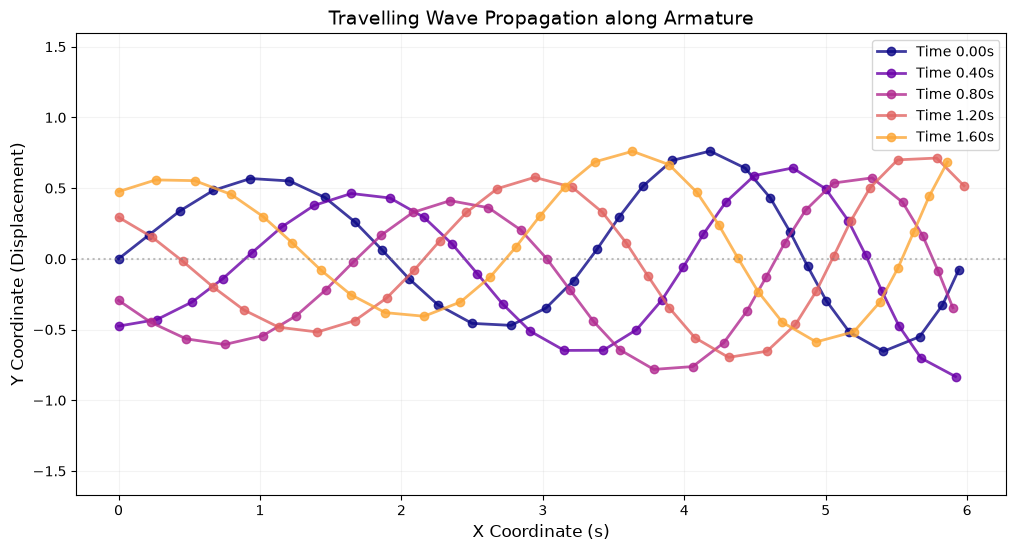

In [3]:
plt.close('all')
plt.figure(figsize=(12, 6))

distances = np.linspace(0.0, 8.0, 30)
wave_amplitude = 0.5
wave_duration = 2.0
time_stamps = np.linspace(0.0, wave_duration, 5, endpoint=False)  # 5 time steps

animation = _travelling_wave_generator(
    distances=distances,
    wave_amplitude=wave_amplitude,
    wave_duration=wave_duration,
    time_stamps=time_stamps,
    growth_factor=0.15,
    num_waves=2.0,
    phi_s=0.0,
    phi_t=0.0
)

colors = plt.cm.plasma(np.linspace(0, 0.8, len(time_stamps)))

for i, (t, frame) in enumerate(animation.items()):
    pts = np.array(frame)
    plt.plot(pts[:, 0], pts[:, 1], 'o-', label=f"Time {t:.2f}s", color=colors[i], alpha=0.8, linewidth=2)

plt.title("Travelling Wave Propagation along Armature", fontsize=14)
plt.xlabel("X Coordinate (s)", fontsize=12)
plt.ylabel("Y Coordinate (Displacement)", fontsize=12)
plt.axhline(0, color='gray', linestyle=':', alpha=0.5)
plt.grid(True, alpha=0.15)
plt.legend()
plt.axis('equal')
plt.show()


## 4. Flicker-Free Interactive Simulator
Use the `Play` widget and configurable parameter sliders to run a real-time animation of the travelling wave.

In [ ]:
from ipywidgets import FloatSlider, IntSlider, Play, jslink, HBox, VBox
import ipywidgets as widgets
from IPython.display import display

plt.close('all')

# Set up the Play widget for loop animation (frames 0 to 99)
play = Play(
    value=0,
    min=0,
    max=99,
    step=1,
    interval=40,  # ~25 FPS for smooth updates
    description="Play",
    loop=True
)

frame_slider = IntSlider(value=0, min=0, max=99, description='Frame')
jslink((play, 'value'), (frame_slider, 'value'))

# Configurable parameter sliders
amplitude_slider = FloatSlider(value=0.5, min=0.1, max=3.0, step=0.1, description='Amplitude')
growth_slider = FloatSlider(value=0.15, min=-0.5, max=0.5, step=0.05, description='Growth Rate')
waves_slider = FloatSlider(value=1.5, min=0.5, max=5.0, step=0.1, description='Num Waves')
speed_slider = FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Wave Speed')
phi_s_slider = FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.1, description='Phase Spatial')
phi_t_slider = FloatSlider(value=0.0, min=-np.pi, max=np.pi, step=0.1, description='Phase Temporal')

def plot_interactive(frame, wave_amplitude, growth_factor, num_waves, wave_speed, phi_s, phi_t):
    plt.close('all')
    
    distances = np.linspace(0.0, 10.0, 50)
    wave_duration = 2.0  # Fixed 2-second base duration
    
    # Calculate current time step in seconds based on frame
    base_time = (frame / 100.0) * wave_duration
    effective_time = base_time * wave_speed
    
    # Generate frame
    animation = _travelling_wave_generator(
        distances=distances,
        wave_amplitude=wave_amplitude,
        wave_duration=wave_duration,
        time_stamps=effective_time,
        growth_factor=growth_factor,
        num_waves=num_waves,
        phi_s=phi_s,
        phi_t=phi_t
    )
    
    pts = np.array(list(animation.values())[0])
    
    plt.figure(figsize=(12, 6))
    
    # Draw the dynamic wave
    plt.plot(pts[:, 0], pts[:, 1], 'r-o', linewidth=2.5, markersize=5, label=f"Travelling Wave (t = {effective_time:.2f}s)")
    
    # Envelope reference bounds (calculated on actual arc length points)
    envelope_y = wave_amplitude * np.exp(growth_factor * distances)
    plt.plot(pts[:, 0], envelope_y, 'k--', alpha=0.3, label="Exponential Envelope (+)")
    plt.plot(pts[:, 0], -envelope_y, 'k--', alpha=0.3, label="Exponential Envelope (-)")
    
    # Limit Y dynamically to fit the growing envelope bounds
    max_env = wave_amplitude * np.exp(max(0, growth_factor) * 10.0)
    plt.ylim(-max_env * 1.25, max_env * 1.25)
    plt.xlim(-0.5, 10.5)
    
    plt.title("Flicker-Free Animated Travelling Wave Simulator", fontsize=14)
    plt.xlabel("X Coordinate (s)", fontsize=12)
    plt.ylabel("Y Coordinate (Displacement)", fontsize=12)
    plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
    plt.grid(True, alpha=0.2)
    plt.legend(loc="upper left")
    plt.axis('equal')
    plt.show()

# Connect widgets using interactive_output to prevent flickering
out = widgets.interactive_output(
    plot_interactive,
    {
        'frame': frame_slider,
        'wave_amplitude': amplitude_slider,
        'growth_factor': growth_slider,
        'num_waves': waves_slider,
        'wave_speed': speed_slider,
        'phi_s': phi_s_slider,
        'phi_t': phi_t_slider
    }
)

controls = VBox([
    HBox([play, frame_slider]),
    HBox([amplitude_slider, growth_slider]),
    HBox([waves_slider, speed_slider]),
    HBox([phi_s_slider, phi_t_slider])
])

display(controls, out)

Output()

In [8]:
SLOW_MOVEMENT_CONFIG = {
    'amplitude': 0.3,
    'num_waves': 2.3,
    'phase_spatial': -1.04,
    'growth_rate': 0.15,
    'wave_speed': 0.7,
    'phase_temporal': 0
}

In [ ]:
FAST_MOVEMENT_CONFIG = {
    'amplitude': 0.4,
    'num_waves': 1.4,
    'phase_spatial': -1.04,
    'growth_rate': 0.2,
    'wave_speed': 0.7,
    'phase_temporal': 0
}